### Exploring The Android's Corpus available metadata

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('metadata.csv')
print(df.head())

            RT   AGE SEX P/C           IT  AGE.1 SEX.1 P/C.1
0  '01_CF56_1'  56.0   F   C  '01_CF56_1'     56     F     C
1  '02_CM57_2'  57.0   M   C  '02_CM57_2'     57     M     C
2  '09_CF56_3'  56.0   F   C  '18_CM64_3'     64     M     C
3  '21_CF58_3'  58.0   F   C  '20_CM51_3'     51     M     C
4  '22_CF50_3'  50.0   F   C  '22_CF50_3'     50     F     C


In [37]:
df.tail()

,RT,AGE,SEX,P/C,IT,AGE.1,SEX.1,P/C.1
111,'72_PM53_1',53.0,M,P,'33_PM19_3',19,M,P
112,NaN,NaN,NaN,NaN,'47_PF42_2',42,F,P
113,NaN,NaN,NaN,NaN,'51_PF58_2',58,F,P
114,NaN,NaN,NaN,NaN,'54_PF48_3',48,F,P
115,NaN,NaN,NaN,NaN,'68_PF43_3',43,F,P


There are more patients for one task than for the other

In [6]:
# Making three dfs for RT, IT and combined (avoiding duplicates)

rt = df[['RT', 'AGE', 'SEX', 'P/C']].rename(columns={'RT': 'ID'})
rt

,ID,AGE,SEX,P/C
0,'01_CF56_1',56.0,F,C
1,'02_CM57_2',57.0,M,C
2,'09_CF56_3',56.0,F,C
3,'21_CF58_3',58.0,F,C
4,'22_CF50_3',50.0,F,C
...,...,...,...,...
111,'72_PM53_1',53.0,M,P
112,NaN,NaN,NaN,NaN
113,NaN,NaN,NaN,NaN
114,NaN,NaN,NaN,NaN


In [7]:
it = df[['IT', 'AGE.1', 'SEX.1', 'P/C.1']].rename(columns={'IT': 'ID', 'AGE.1': 'AGE', 'SEX.1': 'SEX', 'P/C.1': 'P/C'})
it

,ID,AGE,SEX,P/C
0,'01_CF56_1',56,F,C
1,'02_CM57_2',57,M,C
2,'18_CM64_3',64,M,C
3,'20_CM51_3',51,M,C
4,'22_CF50_3',50,F,C
...,...,...,...,...
111,'33_PM19_3',19,M,P
112,'47_PF42_2',42,F,P
113,'51_PF58_2',58,F,P
114,'54_PF48_3',48,F,P


In [9]:
unique_df = pd.concat([rt, it]).drop_duplicates(subset=['ID']).reset_index(drop=True)
unique_df

,ID,AGE,SEX,P/C
0,'01_CF56_1',56.0,F,C
1,'02_CM57_2',57.0,M,C
2,'09_CF56_3',56.0,F,C
3,'21_CF58_3',58.0,F,C
4,'22_CF50_3',50.0,F,C
...,...,...,...,...
114,'20_PM43_2',43.0,M,P
115,'23_PF55_2',55.0,F,P
116,'60_PF56_x',56.0,F,P
117,'70_PF51_1',51.0,F,P


# Ages RT

In [14]:
rt_ages = rt['AGE'].dropna()
rt_ages

0      56.0
1      57.0
2      56.0
3      58.0
4      50.0
       ... 
107    26.0
108    35.0
109    43.0
110    48.0
111    53.0
Name: AGE, Length: 112, dtype: float64

In [15]:
rt_ages.shape

(112,)

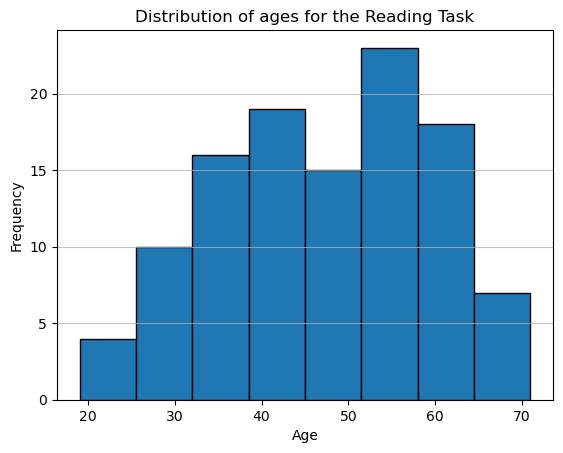

In [16]:
plt.hist(rt_ages, bins='auto', edgecolor='black')
plt.title('Distribution of ages for the Reading Task')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [17]:
import numpy as np

print(f"Mean of the ages in the reading task {np.mean(rt_ages)}")
print(f"Median of the ages in the reading task {np.median(rt_ages)}")
print(f"Standard deviation of the ages in the reading task {np.std(rt_ages)}")

Mean of the ages in the reading task 47.223214285714285
Median of the ages in the reading task 49.5
Standard deviation of the ages in the reading task 12.214386878236029


# Ages IT

In [18]:
it_ages = df['AGE.1'].dropna()
print(it_ages.head())
print(it_ages.shape)

0    56
1    57
2    64
3    51
4    50
Name: AGE.1, dtype: int64
(116,)


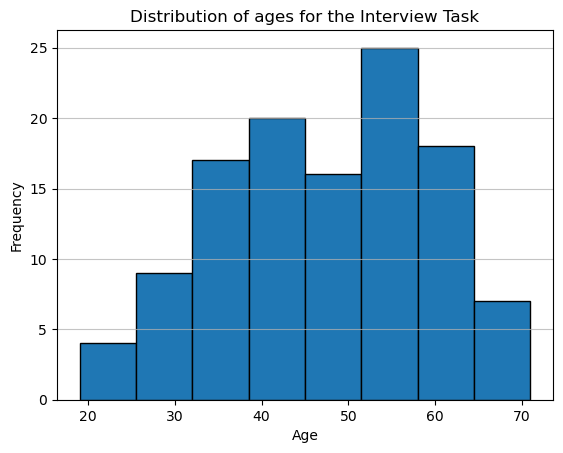

In [19]:
plt.hist(it_ages, bins='auto', edgecolor='black')
plt.title('Distribution of ages for the Interview Task')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [20]:
import numpy as np

print(f"Mean of the ages in the interview task {np.mean(it_ages)}")
print(f"Median of the ages in the interview task {np.median(it_ages)}")
print(f"Standard deviation of the ages in the interview task {np.std(it_ages)}")

Mean of the ages in the interview task 47.38793103448276
Median of the ages in the interview task 50.0
Standard deviation of the ages in the interview task 12.011324793942947


# Ages total

In [22]:
ages = unique_df['AGE'].dropna()
ages

0      56.0
1      57.0
2      56.0
3      58.0
4      50.0
       ... 
114    43.0
115    55.0
116    56.0
117    51.0
118    33.0
Name: AGE, Length: 118, dtype: float64

In [23]:
ages_mean = np.mean(ages)
ages_median = np.median(ages)
ages_std = np.std(ages)

print(f"Mean of the ages in both tasks {ages_mean}")
print(f"Median of the ages in both tasks {ages_median}")
print(f"Standard deviation of the ages in both tasks {ages_std}")

Mean of the ages in both tasks 47.279661016949156
Median of the ages in both tasks 50.0
Standard deviation of the ages in both tasks 12.039402536854249


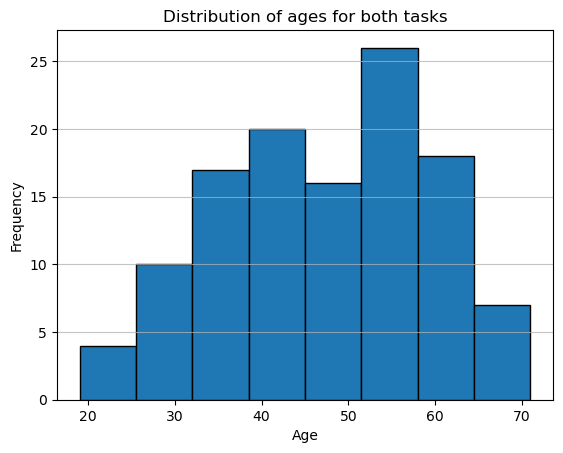

In [24]:
plt.hist(ages, bins='auto', edgecolor='black')
plt.title('Distribution of ages for both tasks')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [25]:
import scipy.stats as stats

# Shapiro-Wilk test for normality
shapiro_rt, p_rt = stats.shapiro(rt_ages)
shapiro_it, p_it = stats.shapiro(it_ages)
shapiro_total, p_total = stats.shapiro(ages)

print(f"Shapiro-Wilk test for Reading Task: {shapiro_rt}, p-value: {p_rt:.4f}")
print(f"Shapiro-Wilk test for Interview Task: {shapiro_it}, p-value: {p_it:.4f}")
print(f"Shapiro-Wilk test for Total Ages: {shapiro_total}, p-value: {p_total:.4f}")

Shapiro-Wilk test for Reading Task: 0.9763638180600743, p-value: 0.0442
Shapiro-Wilk test for Interview Task: 0.9771992557144765, p-value: 0.0452
Shapiro-Wilk test for Total Ages: 0.9762698077633447, p-value: 0.0346


### Rejecting $H_0$ of the Shapiro-Wilk test, the population is not normally distributed because p-value $< \alpha$, where $\alpha = 0.05$

### While the original authors describe the age distribution as normal, the Shapiro-Wilk test on deduplicated unique subject pool indicates a marginal deviation from strict normality. The skewness remains small enough.

Moreover, the authors do not indicate which test they performed to check the distribution of age amongst the participants and they do not indicate their chosen level of significance.

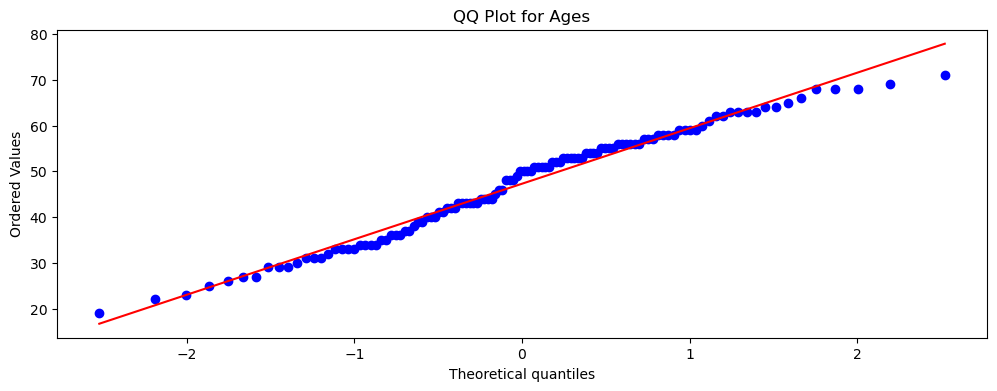

In [26]:
# Checking with a QQ plot

plt.figure(figsize=(12, 4))
stats.probplot(ages, dist="norm", plot=plt)
plt.title('QQ Plot for Ages')
plt.show()

Dots curv away at the end

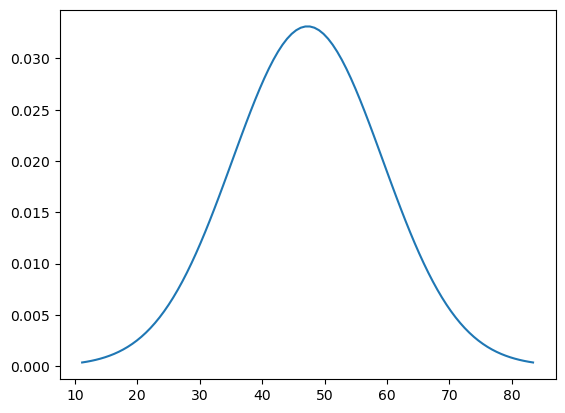

In [27]:
# Plotting THE curve
import math

mu = ages_mean
variance = 1
sigma = ages_std
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.show()

In [28]:
q1, q3 = np.percentile(ages, [25, 75])

print(f"Q1 (25th percentile) of ages: {q1}")
print(f"Q3 (75th percentile) of ages: {q3}")

Q1 (25th percentile) of ages: 37.25
Q3 (75th percentile) of ages: 56.0


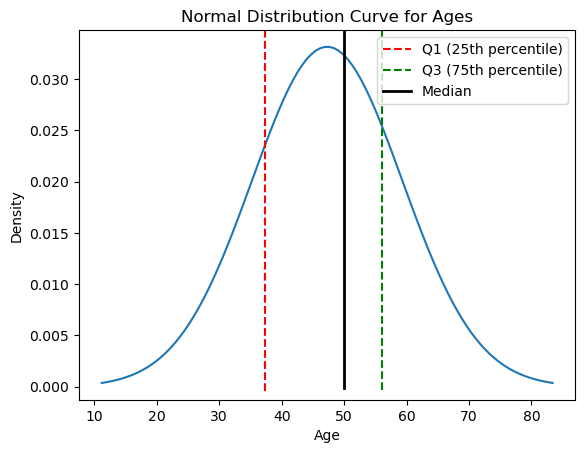

In [29]:
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.axvline(q1, stats.norm.pdf(q1, mu, sigma), color='red', linestyle='--', label='Q1 (25th percentile)')
plt.axvline(q3, stats.norm.pdf(q3, mu, sigma), color='green', linestyle='--', label='Q3 (75th percentile)')
plt.axvline(ages_median, stats.norm.pdf(ages_median, mu, sigma), color='black', linestyle='-', linewidth=2, label='Median')
plt.title('Normal Distribution Curve for Ages')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

The distribution is not highly skewed

# Depressed (P) and Control (C) participants for each group

In [31]:
unique_df.head()

,ID,AGE,SEX,P/C
0,'01_CF56_1',56.0,F,C
1,'02_CM57_2',57.0,M,C
2,'09_CF56_3',56.0,F,C
3,'21_CF58_3',58.0,F,C
4,'22_CF50_3',50.0,F,C


In [34]:
rt_depressed = rt[rt['P/C'] == 'P']['P/C']
rt_control = rt[rt['P/C'] == 'C']['P/C']

it_depressed = it[it['P/C'] == 'P']['P/C']
it_control = it[it['P/C'] == 'C']['P/C']

print(f"Depressed patients in the RT: {rt_depressed.count()}")
print(f"Control patients in the RT: {rt_control.count()}")
print(f"Depressed patients in the IT: {it_depressed.count()}")
print(f"Control patients in the IT: {it_control.count()}")

Depressed patients in the RT: 58
Control patients in the RT: 54
Depressed patients in the IT: 64
Control patients in the IT: 52


In [35]:
total_depressed = unique_df[unique_df['P/C'] == 'P']['P/C']
total_control = unique_df[unique_df['P/C'] == 'C']['P/C']

print(f"Total depressed patients: {total_depressed.count()}")
print(f"Total control patients: {total_control.count()}")

Total depressed patients: 64
Total control patients: 54


# Sex of the participants

In [36]:
rt_females = rt[rt['SEX'] == 'F']['SEX']
rt_males = rt[rt['SEX'] == 'M']['SEX']

it_females = it[it['SEX'] == 'F']['SEX']
it_males = it[it['SEX'] == 'M']['SEX']

print(f"Females in the RT: {rt_females.count()}")
print(f"Males in the RT: {rt_males.count()}")
print(f"Females in the IT: {it_females.count()}")
print(f"Males in the IT: {it_males.count()}")


Females in the RT: 80
Males in the RT: 32
Females in the IT: 84
Males in the IT: 32


In [37]:
total_females = unique_df[unique_df['SEX'] == 'F']['SEX']
total_males = unique_df[unique_df['SEX'] == 'M']['SEX']

print(f"Total females: {total_females.count()}")
print(f"Total males: {total_males.count()}")


Total females: 85
Total males: 33


# Correlation of sex and depressed/not depressed in this dataset

$H_0$ sex and depression are independent

$H_1$ sex and depression are dependent

In [42]:
from scipy.stats import chi2_contingency

# Contingency table of SEX vs P/C
contingency_table = pd.crosstab(unique_df['SEX'], unique_df['P/C'])


chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic: {chi2}")
print(f"P-value: {p}")

Chi-square Statistic: 1.1472343945995904
P-value: 0.28412883685963747


Degrees of freedom is $1$ based on the fact that both SEX and P/C have two categories

In [40]:
contingency_table

P/C,C,P
SEX,,
F,42,43
M,12,21


p $> 0.05$, we fail to reject $H_0$ - data does not provide sufficient evidence to suggest a dependency between the variables. The higher number of deressed women is due to sample composition, i.e. more women being present. The authors of the dataset justified the choice of interviewing more women. 